# 07 Field3 Fine-tuning v2 결과 분석

이 노트북은 `06_field3_finetune_v2_colab.ipynb`에서 수행한 CLRKDNet field3 파인튜닝 결과를 정리하는 분석 노트북임.

이번 단계의 질문은 아래 3개임.

1. Colab에서 내려온 결과가 정상적으로 보관되었는가?
2. A/B 실험 중 어떤 checkpoint가 현재 가장 유망한가?
3. 다음 시각 검증/ONNX export에서 어떤 모델을 기준 후보로 삼을 것인가?

이번 노트북은 우선 로그와 metric 중심으로 판단함. 실제 주행 이미지 위에 예측 lane을 그려보는 시각 검증은 다음 노트북에서 이어서 수행함.


## 0. 경로 설정

Colab 결과 zip은 아래 위치에 보관해두었음.

```text
10_experiments/11_clrkdnet_precision_tuning/colab_outputs/field3_finetune_v2/raw_zips
```

압축 해제본은 Windows path length 문제 때문에 전체 code snapshot을 모두 풀지 않고, 분석에 필요한 `log.txt`, `config.py`, `ckpt/*.pth`, summary 파일만 선택적으로 풀어둔 상태임. 원본 zip 안에는 전체 결과가 그대로 남아 있음.


In [1]:
from pathlib import Path
import re, json, csv, math

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization")
EXP_DIR = ROOT / "10_experiments" / "11_clrkdnet_precision_tuning"
COLAB_DIR = EXP_DIR / "colab_outputs" / "field3_finetune_v2"
OUTPUTS_DIR = COLAB_DIR / "outputs"
RAW_ZIPS_DIR = COLAB_DIR / "raw_zips"
REVIEW_DIR = EXP_DIR / "review_outputs" / "07_field3_finetune_v2_result_review"
DATASET_DIR = EXP_DIR / "datasets" / "field3_v1"
PREV_V1_DIR = ROOT / "10_experiments" / "06_lane_model_finetuning" / "colab_outputs" / "finetune_v1"

print('EXP_DIR:', EXP_DIR)
print('COLAB_DIR:', COLAB_DIR, COLAB_DIR.exists())
print('OUTPUTS_DIR:', OUTPUTS_DIR, OUTPUTS_DIR.exists())
print('RAW_ZIPS_DIR:', RAW_ZIPS_DIR, RAW_ZIPS_DIR.exists())
print('REVIEW_DIR:', REVIEW_DIR, REVIEW_DIR.exists())
print('DATASET_DIR:', DATASET_DIR, DATASET_DIR.exists())


EXP_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning
COLAB_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\colab_outputs\field3_finetune_v2 True
OUTPUTS_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\colab_outputs\field3_finetune_v2\outputs True
RAW_ZIPS_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\colab_outputs\field3_finetune_v2\raw_zips True
REVIEW_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\07_field3_finetune_v2_result_review True
DATASET_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\datasets\field3_v1 True


## 1. 결과 파일 인벤토리

먼저 Colab 결과가 제대로 들어왔는지 확인함. 핵심은 각 run의 `log.txt`, `config.py`, `ckpt/best.pth` 존재 여부임.


In [2]:
run_dirs = {
    'A_smoke': OUTPUTS_DIR / 'MapLane_Field3_A_pretrained_to_field3_smoke' / '20260507_204651_lr_1e-04_b_8',
    'A_full': OUTPUTS_DIR / 'MapLane_Field3_A_pretrained_to_field3_full' / '20260507_210252_lr_1e-04_b_8',
    'B_smoke': OUTPUTS_DIR / 'MapLane_Field3_B_field12best_to_field3_smoke' / '20260507_204827_lr_5e-05_b_8',
    'B_full': OUTPUTS_DIR / 'MapLane_Field3_B_field12best_to_field3_full' / '20260507_205319_lr_5e-05_b_8',
}

inventory = []
for run_id, d in run_dirs.items():
    log = d / 'log.txt'
    cfg = d / 'config.py'
    best = d / 'ckpt' / 'best.pth'
    ckpts = sorted((d / 'ckpt').glob('*.pth')) if (d / 'ckpt').exists() else []
    inventory.append({
        'run_id': run_id,
        'run_dir_exists': d.exists(),
        'log_exists': log.exists(),
        'config_exists': cfg.exists(),
        'best_exists': best.exists(),
        'best_MB': round(best.stat().st_size / 1024 / 1024, 2) if best.exists() else None,
        'ckpt_count': len(ckpts),
        'ckpts': ', '.join(p.name for p in ckpts),
        'run_dir': str(d),
    })

inventory_df = pd.DataFrame(inventory)
display(inventory_df)


,run_id,run_dir_exists,log_exists,config_exists,best_exists,best_MB,ckpt_count,ckpts,run_dir
0,A_smoke,True,True,True,True,131.63,2,"0.pth, best.pth",~\02_Projects\University\26-1_Em...
1,A_full,True,True,True,True,131.63,7,"1.pth, 11.pth, 3.pth, 5.pth, 7.pth, 9.pth, bes...",~\02_Projects\University\26-1_Em...
2,B_smoke,True,True,True,True,131.63,2,"0.pth, best.pth",~\02_Projects\University\26-1_Em...
3,B_full,True,True,True,True,131.63,5,"1.pth, 3.pth, 5.pth, 7.pth, best.pth",~\02_Projects\University\26-1_Em...


## 2. 로그 파싱

각 run의 `log.txt`에서 아래 정보를 추출함.

- `metric`: CLRKDNet recorder가 best 판단에 사용하는 validation F1@0.5
- `Best metric`, `epoch_best`
- 학습 중 출력된 loss history

주의: 현재 CULane category split 쪽 `test0_normal`은 생성 dataset과 맞지 않아 0으로 찍히는 부분이 있음. 최종 판단은 recorder의 `metric`, 즉 `val.txt` 기준 결과를 사용함.


In [3]:
def parse_log(run_id: str, run_dir: Path):
    log = run_dir / 'log.txt'
    txt = log.read_text(encoding='utf-8', errors='replace') if log.exists() else ''
    metrics = [float(m) for m in re.findall(r'metric:\s*([0-9.]+)', txt)]
    bests = re.findall(r'Best metric:\s*([0-9.]+)\s+epoch_best:(\d+)', txt)
    loss_rows = []
    for m in re.finditer(
        r'epoch:\s*(\d+)\s+step:\s*(\d+)\s+lr:\s*([0-9.eE+-]+)\s+loss:\s*([0-9.]+).*?'
        r'cls_loss:\s*([0-9.]+).*?reg_xytl_loss:\s*([0-9.]+).*?seg_loss:\s*([0-9.]+).*?iou_loss:\s*([0-9.]+)',
        txt,
    ):
        loss_rows.append({
            'run_id': run_id,
            'epoch': int(m.group(1)),
            'step': int(m.group(2)),
            'lr': float(m.group(3)),
            'loss': float(m.group(4)),
            'cls_loss': float(m.group(5)),
            'reg_xytl_loss': float(m.group(6)),
            'seg_loss': float(m.group(7)),
            'iou_loss': float(m.group(8)),
        })
    best_metric = float(bests[-1][0]) if bests else (metrics[-1] if metrics else None)
    best_epoch = int(bests[-1][1]) if bests else None
    return {
        'run_id': run_id,
        'best_metric': best_metric,
        'best_epoch': best_epoch,
        'metric_history': metrics,
        'first_loss': loss_rows[0]['loss'] if loss_rows else None,
        'last_loss': loss_rows[-1]['loss'] if loss_rows else None,
        'last_cls_loss': loss_rows[-1]['cls_loss'] if loss_rows else None,
        'last_reg_xytl_loss': loss_rows[-1]['reg_xytl_loss'] if loss_rows else None,
        'last_seg_loss': loss_rows[-1]['seg_loss'] if loss_rows else None,
        'last_iou_loss': loss_rows[-1]['iou_loss'] if loss_rows else None,
        'loss_rows': loss_rows,
    }

parsed = [parse_log(run_id, d) for run_id, d in run_dirs.items()]
summary_rows = []
loss_rows = []
for item in parsed:
    run_id = item['run_id']
    exp_key, phase = run_id.split('_', 1)
    label = 'pretrained_to_field3' if exp_key == 'A' else 'field12best_to_field3'
    summary_rows.append({
        'run_id': run_id,
        'experiment': exp_key,
        'phase': phase,
        'label': label,
        'best_metric': item['best_metric'],
        'best_epoch': item['best_epoch'],
        'first_loss': item['first_loss'],
        'last_loss': item['last_loss'],
        'last_cls_loss': item['last_cls_loss'],
        'last_reg_xytl_loss': item['last_reg_xytl_loss'],
        'last_seg_loss': item['last_seg_loss'],
        'last_iou_loss': item['last_iou_loss'],
        'best_ckpt': str(run_dirs[run_id] / 'ckpt' / 'best.pth'),
    })
    for row in item['loss_rows']:
        row = dict(row)
        row['experiment'] = exp_key
        row['phase'] = phase
        row['label'] = label
        loss_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values('best_metric', ascending=False)
loss_df = pd.DataFrame(loss_rows)
display(summary_df)


,run_id,experiment,phase,label,best_metric,best_epoch,first_loss,last_loss,last_cls_loss,last_reg_xytl_loss,last_seg_loss,last_iou_loss,best_ckpt
3,B_full,B,full,field12best_to_field3,0.450055,7,1.9813,1.7527,0.5637,0.3609,0.1172,0.7109,~\02_Projects\University\26-1_Em...
2,B_smoke,B,smoke,field12best_to_field3,0.410989,0,1.9813,2.1850,0.6076,0.4643,0.1357,0.9774,~\02_Projects\University\26-1_Em...
1,A_full,A,full,pretrained_to_field3,0.362822,11,5.8952,2.3853,0.7054,0.4553,0.1303,1.0942,~\02_Projects\University\26-1_Em...
0,A_smoke,A,smoke,pretrained_to_field3,0.190476,0,5.8952,3.5997,0.7126,0.9977,0.2080,1.6813,~\02_Projects\University\26-1_Em...


## 3. 결과 비교

이번 실험의 핵심 비교는 `A full`과 `B full`임.

- A: 공식 pretrained에서 field3만 학습
- B: field1+2 파인튜닝 best에서 field3 추가 학습

B가 더 좋다면, 지금까지의 누적 도메인 적응이 field3에도 유효하다는 뜻임.


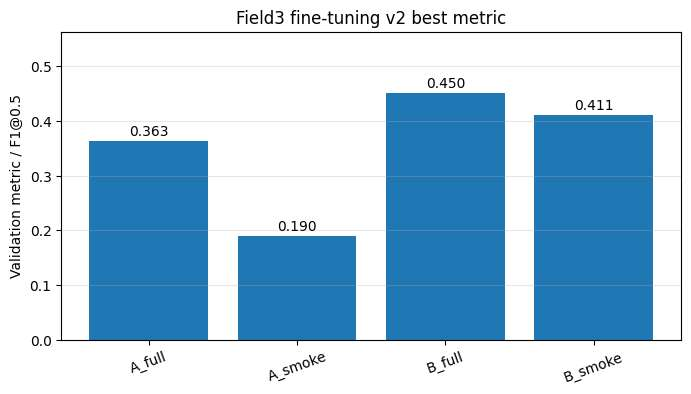

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = summary_df.sort_values('run_id')
ax.bar(plot_df['run_id'], plot_df['best_metric'])
ax.set_title('Field3 fine-tuning v2 best metric')
ax.set_ylabel('Validation metric / F1@0.5')
ax.set_ylim(0, max(plot_df['best_metric'].fillna(0)) * 1.25)
for idx, row in plot_df.iterrows():
    ax.text(row['run_id'], row['best_metric'] + 0.01, f"{row['best_metric']:.3f}", ha='center')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.show()


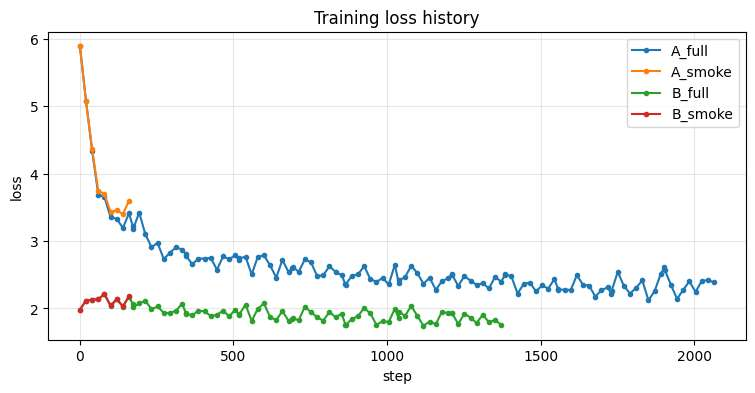

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
for run_id, group in loss_df.groupby('run_id'):
    # 너무 조밀하게 보이지 않도록 log interval 기준 출력 loss만 이어 그림.
    ax.plot(group['step'], group['loss'], marker='o', linewidth=1.5, markersize=3, label=run_id)
ax.set_title('Training loss history')
ax.set_xlabel('step')
ax.set_ylabel('loss')
ax.grid(alpha=0.3)
ax.legend()
plt.show()


In [6]:
# epoch별 마지막 logged loss만 따로 보기
if not loss_df.empty:
    epoch_last = loss_df.sort_values(['run_id', 'epoch', 'step']).groupby(['run_id', 'epoch']).tail(1)
    display(epoch_last[['run_id', 'epoch', 'step', 'lr', 'loss', 'cls_loss', 'reg_xytl_loss', 'seg_loss', 'iou_loss']])


,run_id,epoch,step,lr,loss,cls_loss,reg_xytl_loss,seg_loss,iou_loss
18,A_full,0,173,0.000098,3.2218,0.7156,0.8129,0.1844,1.5090
28,A_full,1,346,0.000093,2.8041,0.6873,0.6656,0.1466,1.3045
38,A_full,2,519,0.000085,2.7185,0.6971,0.5833,0.1417,1.2964
48,A_full,3,692,0.000075,2.5995,0.6749,0.5195,0.1390,1.2661
58,A_full,4,865,0.000063,2.3570,0.6626,0.4848,0.1314,1.0783
68,A_full,5,1038,0.000050,2.3774,0.6573,0.4695,0.1316,1.1191
78,A_full,6,1211,0.000037,2.5057,0.6534,0.5519,0.1291,1.1713
88,A_full,7,1384,0.000024,2.5014,0.6816,0.5046,0.1290,1.1862
98,A_full,8,1557,0.000014,2.2835,0.6983,0.4430,0.1268,1.0155
108,A_full,9,1730,0.000006,2.2198,0.6979,0.3595,0.1332,1.0291


## 4. 이전 v1 결과와 비교

이전 field1+2 full fine-tuning 결과는 `metric ≈ 0.4761`이었음. 다만 그 metric은 field1+2 validation split 기준이고, 이번 `0.4501`은 field3 validation split 기준이라 직접적인 우열 비교는 아님.

중요한 해석은 아래임.

- field1+2 데이터에서 학습된 모델은 field3 실제 주행 데이터에 대해 이미 A보다 좋은 출발점을 제공함.
- field3를 추가 학습한 B full은 smoke보다 metric이 더 올라감.
- 따라서 “field1+2 → field3 추가 적응” 흐름은 계속 가져갈 가치가 있음.


In [7]:
# 이전 v1 결과는 전체 colab_outputs를 rglob로 훑지 않음.
# Colab prediction 결과 폴더 중 일부가 Windows long path / 깨진 경로처럼 동작해서 rglob가 중간에 죽을 수 있기 때문임.
prev_full_run = PREV_V1_DIR / 'MapLane_Field1Field2_full' / '20260505_201647_lr_1e-04_b_8'
prev_log_candidates = [prev_full_run / 'log.txt']

print('previous v1 full run:', prev_full_run)
print('exists:', prev_full_run.exists())
print('previous v1 full logs:', sum(p.exists() for p in prev_log_candidates))
for p in prev_log_candidates:
    print(p)
    if not p.exists():
        print('best:', None)
        continue
    txt = p.read_text(encoding='utf-8', errors='replace')
    bests = re.findall(r'Best metric:\s*([0-9.]+)\s+epoch_best:(\d+)', txt)
    print('best:', bests[-1] if bests else None)


previous v1 full run: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8
exists: True
previous v1 full logs: 1
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\log.txt
best: ('0.47607589079130036', '11')


## 5. 현재 best checkpoint 선정

현재 로그 기준 best 후보는 `B_full`임.

```text
B_full = field1+2 best -> field3 추가 fine-tuning
best metric = 0.45005488474204175
epoch_best = 7
```

이 모델이 다음 단계의 기본 후보가 됨.


In [8]:
best_row = summary_df.iloc[0].to_dict()
print(json.dumps(best_row, ensure_ascii=False, indent=2))

registry = {
    'selected_candidate': best_row['run_id'],
    'selected_checkpoint': best_row['best_ckpt'],
    'selected_metric': best_row['best_metric'],
    'reason': 'field3 validation metric 기준 최상위. field1+2 best에서 field3로 추가 적응한 B_full이 현재 주행모델 후보.',
    'all_runs': summary_df.to_dict(orient='records'),
}
REVIEW_DIR.mkdir(parents=True, exist_ok=True)
(REVIEW_DIR / 'selected_checkpoint_registry_from_notebook.json').write_text(
    json.dumps(registry, ensure_ascii=False, indent=2), encoding='utf-8'
)
print('saved:', REVIEW_DIR / 'selected_checkpoint_registry_from_notebook.json')


{
  "run_id": "B_full",
  "experiment": "B",
  "phase": "full",
  "label": "field12best_to_field3",
  "best_metric": 0.45005488474204175,
  "best_epoch": 7,
  "first_loss": 1.9813,
  "last_loss": 1.7527,
  "last_cls_loss": 0.5637,
  "last_reg_xytl_loss": 0.3609,
  "last_seg_loss": 0.1172,
  "last_iou_loss": 0.7109,
  "best_ckpt": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\11_clrkdnet_precision_tuning\\colab_outputs\\field3_finetune_v2\\outputs\\MapLane_Field3_B_field12best_to_field3_full\\20260507_205319_lr_5e-05_b_8\\ckpt\\best.pth"
}
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\07_field3_finetune_v2_result_review\selected_checkpoint_registry_from_notebook.json


## 6. 분석 결과 메모

현재까지의 결론:

- Colab 결과는 정상적으로 보관됨.
- `A smoke`, `A full`, `B smoke`, `B full` 모두 `best.pth`가 생성됨.
- best metric 기준 현재 최선은 `B_full`임.
- `B_full`은 기존 field1+2 fine-tuned 모델을 field3 실제 주행 데이터로 추가 학습한 결과임.
- 따라서 다음 시각 검증/ONNX export는 `B_full best.pth`를 우선 사용함.

단, 여기서 끝난 것은 아님. validation metric이 좋아졌다는 것은 lane output이 GT와 더 잘 맞는다는 신호지만, 실제 주행에서는 아래가 더 중요함.

- 직선에서 중심이 안정적인가?
- 코너에서 lane 후보가 끊기지 않는가?
- 한쪽 lane만 보일 때 후처리로 제어 가능한가?
- 교차로에서 잘못된 lane을 과하게 선택하지 않는가?

따라서 다음 단계는 `B_full best.pth`를 실제 field3 이미지에 overlay해서 보는 시각 검증임.


## 7. 다음 노트북 연결

다음 노트북에서 할 작업:

```text
08_field3_visual_compare_and_postprocess_check.ipynb
```

목표:

1. `field1+2 v1 best`와 `field3 v2 B_full best`를 같은 field3 이미지에 대해 비교함.
2. official lane detector postprocess 결과를 이미지 overlay로 확인함.
3. 주행 postprocess로 넘길 lane 후보가 실제로 살아났는지 판단함.
4. 괜찮다면 ONNX export 후보로 확정함.
5. 안 되면 CLRKDNet을 계속 살릴지, 더 단순한 segmentation/HSV 기반 모델로 전환할지 재판단함.


In [9]:
# 다음 노트북에서 바로 사용할 경로 메모
next_inputs = {
    'field3_dataset': str(DATASET_DIR),
    'field3_v2_best_checkpoint': str(Path(best_row['best_ckpt'])),
    'field3_v2_best_run': best_row['run_id'],
    'field3_v2_best_metric': best_row['best_metric'],
    'field3_v2_outputs': str(OUTPUTS_DIR),
    'review_dir': str(REVIEW_DIR),
}
print(json.dumps(next_inputs, ensure_ascii=False, indent=2))
(REVIEW_DIR / 'next_visual_review_inputs.json').write_text(json.dumps(next_inputs, ensure_ascii=False, indent=2), encoding='utf-8')


{
  "field3_dataset": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\11_clrkdnet_precision_tuning\\datasets\\field3_v1",
  "field3_v2_best_checkpoint": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\11_clrkdnet_precision_tuning\\colab_outputs\\field3_finetune_v2\\outputs\\MapLane_Field3_B_field12best_to_field3_full\\20260507_205319_lr_5e-05_b_8\\ckpt\\best.pth",
  "field3_v2_best_run": "B_full",
  "field3_v2_best_metric": 0.45005488474204175,
  "field3_v2_outputs": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\11_clrkdnet_precision_tuning\\colab_outputs\\field3_finetune_v2\\outputs",
  "review_dir": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\11_clrkdnet_precision_tuning\\review_outputs\\07_field3_finetune_v2_result_review"
}


967